Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8158 - loss: 0.5209 - val_accuracy: 0.8573 - val_loss: 0.4025
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8628 - loss: 0.3786 - val_accuracy: 0.8612 - val_loss: 0.3850
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8763 - loss: 0.3376 - val_accuracy: 0.8648 - val_loss: 0.3696
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8860 - loss: 0.3142 - val_accuracy: 0.8836 - val_loss: 0.3324
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8892 - loss: 0.2986 - val_accuracy: 0.8826 - val_loss: 0.3245
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8955 - loss: 0.2805 - val_accuracy: 0.8802 - val_loss: 0.3403
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9004 - loss: 0.2666 - val_accuracy: 0.8810 - val_loss: 0.3345
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9021 - loss: 0.2609 - 

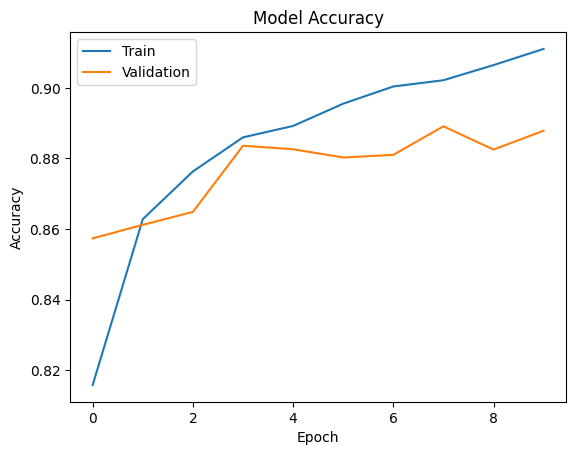

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


X_train = X_train / 255.0
X_test = X_test / 255.0


X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)


model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])


model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


history = model.fit(X_train, y_train, epochs=10, validation_split=0.2)


test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8112 - loss: 0.5415 - val_accuracy: 0.8263 - val_loss: 0.4580
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8447 - loss: 0.4265 - val_accuracy: 0.8489 - val_loss: 0.4090
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8555 - loss: 0.3958 - val_accuracy: 0.8618 - val_loss: 0.3905
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8656 - loss: 0.3710 - val_accuracy: 0.8697 - val_loss: 0.3598
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8671 - loss: 0.3583 - val_accuracy: 0.8728 - val_loss: 0.3520
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8743 - loss: 0.3425 - val_accuracy: 0.8709 - val_loss: 0.3547
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8784 - loss: 0.3319 - val_accuracy: 0.8698 - val_loss: 0.3509
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8809 - loss: 0.3229 - val_accuracy: 0.

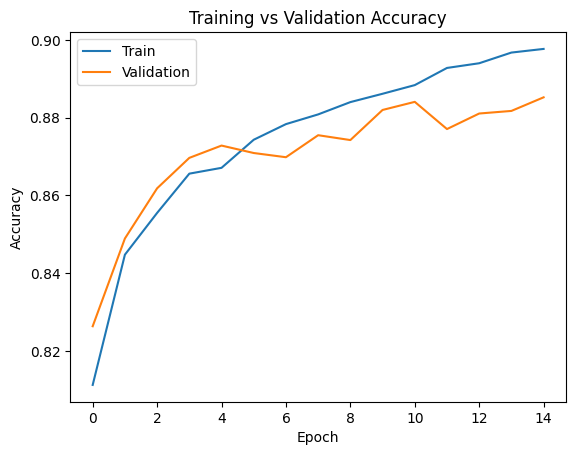

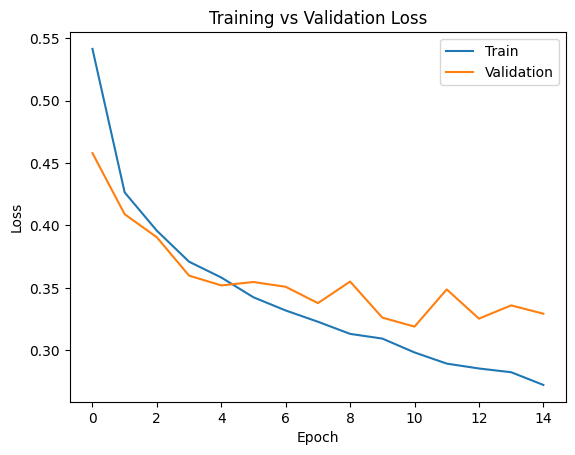

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


X_train = X_train / 255.0
X_test = X_test / 255.0


X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)


model = models.Sequential([

    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(10, activation='softmax')
])


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)


test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend(['Train', 'Validation'])
plt.show()